<a href="https://colab.research.google.com/github/danhdo31251023363-ops/BTVN-s-1/blob/main/BTVN_S%E1%BB%90_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
#23.1
import folium
center = [10.761158591008995, 106.66836872262138]
m=folium.Map(location=center,zoom_start=13)
folium.Marker(location=center,popup='UEH',icon=folium.Icon(color="red")).add_to(m)
places=[("Bệnh viện Từ Dũ", [10.7685, 106.6854]),("Vincom Center", [10.777949018277171, 106.7017239331524]),("Bến xe Miền Đông", [10.880604172595033, 106.81490700913099]),("UBND Quận 1", [10.776, 106.701]),("Coopmart", [10.78078048550373, 106.69947601584889])]
for name, coord in places:
  folium.Marker(location=coord,popup=name).add_to(m)
m

In [14]:
#23.2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
geo = Nominatim(user_agent="app", timeout=10)
center = geo.geocode("UEH Ho Chi Minh City")
c = (center.latitude, center.longitude)
places = ["Ben Thanh Market","Vincom Center Ho Chi Minh","Cho Ray Hospital","Tan Son Nhat Airport","Landmark 81 Ho Chi Minh","Nguyen Hue Walking Street","Bitexco Tower","Saigon Zoo","Dinh Doc Lap", "Nha Tho Duc Ba"]
m = folium.Map(location=c, zoom_start=13)
folium.Marker(c, popup="UEH", icon=folium.Icon(color="red")).add_to(m)
for p in places:
    loc = geo.geocode(p)
    if loc:
        coord = (loc.latitude, loc.longitude)
        d = geodesic(c, coord).km
        folium.Marker(
            coord,
            popup=f"{p}: {d:.2f} km"
        ).add_to(m)
        folium.PolyLine([c, coord], color="blue").add_to(m)
m

In [ ]:
#23.3
from folium.plugins import HeatMap
import random
center = [10.76, 106.66]
data = []
for _ in range(100):
    lat = 10.75 + random.random() * 0.05
    lon = 106.65 + random.random() * 0.05
    data.append([lat, lon])
m = folium.Map(location=center, zoom_start=13)
HeatMap(data).add_to(m)
m

In [50]:
#23.4
import geopandas as gpd
import pandas as pd
import folium
from shapely.geometry import Polygon
import json
polygons = [
    Polygon([(106.68, 10.77), (106.70, 10.77), (106.70, 10.79), (106.68, 10.79)]),
    Polygon([(106.70, 10.77), (106.72, 10.77), (106.72, 10.79), (106.70, 10.79)]),
    Polygon([(106.68, 10.75), (106.70, 10.75), (106.70, 10.77), (106.68, 10.77)]),
    Polygon([(106.70, 10.75), (106.72, 10.75), (106.72, 10.77), (106.70, 10.77)])
]
khu_vuc = ['Khu vực Trung tâm', 'Khu vực phía Đông', 'Khu vực phía Nam', 'Khu vực Đông Nam']
so_luong_don = [2500, 900, 1000, 300]
# Tạo GeoDataFrame
gdf = gpd.GeoDataFrame({
    'Khu_Vuc': khu_vuc,
    'Don_Hang': so_luong_don
}, geometry=polygons, crs="EPSG:4326")
m = folium.Map(location=[10.77, 106.70], zoom_start=13, tiles='CartoDB positron')
# Chuyển GeoDataFrame thành định dạng JSON để Folium đọc được
geo_json_data = json.loads(gdf.to_json())
# Tạo lớp Choropleth
folium.Choropleth(
    geo_data=geo_json_data,
    name='Mật độ đơn hàng',
    data=gdf,
    columns=['Khu_Vuc', 'Don_Hang'],
    key_on='feature.properties.Khu_Vuc',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='Số lượng đơn hàng (đơn/ngày)'
).add_to(m)
# Thêm GeoJson Tooltip
folium.GeoJson(
    geo_json_data,
style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 1},
    tooltip=folium.GeoJsonTooltip(
        fields=['Khu_Vuc', 'Don_Hang'],
        aliases=['Khu vực:', 'Số đơn hàng:'],
        localize=True
    )
).add_to(m)
folium.LayerControl().add_to(m)
print("Bản đồ Choropleth đã được tạo thành công!")
m

Bản đồ Choropleth đã được tạo thành công!


In [54]:
#23.5
import folium
import random
# Tọa độ kho hàng
kho_center = [10.7725221,106.6954459]
# Tạo bản đồ
m = folium.Map(location=kho_center, zoom_start=13)
# Đánh dấu vị trí kho bằng icon màu đỏ
folium.Marker(
    location=kho_center,
    popup="<b>Kho Trung Tâm (Ben Thanh)</b>",
    icon=folium.Icon(color='black', icon='home', prefix='fa')
).add_to(m)
folium.Circle( # Vẽ vòng bán kính
    location=kho_center,
    radius=3000,
    color='blue',
    weight=2,
    fill=True,
    fill_opacity=0.15,
    popup="Vùng phục vụ 3km"
).add_to(m)
folium.Circle( # Vẽ vòng bán kính
    location=kho_center,
    radius=6000,
    color='red',
    weight=2,
    fill=True,
    fill_opacity=0.1,
    popup="Vùng phục vụ 6km"
).add_to(m)
folium.Circle( # Vẽ vòng bán kính
    location=kho_center,
    radius=9000,
    color='green',
    weight=2,
    fill=True,
    fill_opacity=0.05,
    popup="Vùng phục vụ 9km"
).add_to(m)

random.seed(42)
for _ in range(100):
    lat = kho_center[0] + random.uniform(-0.19, 0.19)
    lng = kho_center[1] + random.uniform(-0.19, 0.19)

    folium.CircleMarker(
        location=[lat, lng],
        radius=3,
        color='black',
        fill=True,
        fill_color='black',
        fill_opacity=0.6
    ).add_to(m)
folium.plugins.MeasureControl().add_to(m)
m

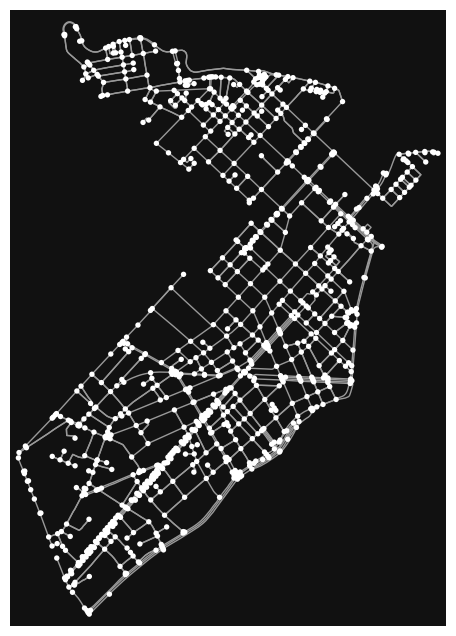

KẾT QUẢ PHÂN TÍCH
Số nút giao: 985
Số đoạn đường: 2081
Chiều dài trung bình (m): 79.3
Diện tích (km²): 8.03
Mật độ mạng (đường/km²): 259.19


In [16]:
#23.6
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")
fig, ax = ox.plot_graph(G)
num_nodes = len(G.nodes)
num_edges = len(G.edges)
lengths = [data['length'] for u, v, data in G.edges(data=True)]
avg_length = sum(lengths) / len(lengths)
area_gdf = ox.geocode_to_gdf(place)
area_proj = area_gdf.to_crs(epsg=3857)
area_km2 = area_proj.area.iloc[0] / 1e6
density = num_edges / area_km2
print("KẾT QUẢ PHÂN TÍCH")
print("Số nút giao:", num_nodes)
print("Số đoạn đường:", num_edges)
print("Chiều dài trung bình (m):", round(avg_length, 2))
print("Diện tích (km²):", round(area_km2, 2))
print("Mật độ mạng (đường/km²):", round(density, 2))

In [24]:
#23.7
import folium
from geopy.geocoders import Nominatim
import osmnx as ox
import networkx as nx
address_A = "Ben Thanh Market, Ho Chi Minh City, Vietnam"
address_B = "254 Hoa Hung, Ho Chi Minh City, Vietnam"
geolocator = Nominatim(user_agent="routing-example", timeout=10)
location_A = geolocator.geocode(address_A)
location_B = geolocator.geocode(address_B)
latlng_A = (10.7725221,106.6954459)
latlng_B = (10.7785107,106.6696111)
# Đi theo mạng lưới đường bộ trong khu vực giữa điểm A và điểm B, bán kính khoảng 3km
midpoint = ((latlng_A[0] + latlng_B[0]) / 2, (latlng_A[1] + latlng_B[1]) / 2)
G = ox.graph_from_point(midpoint, dist=3000, network_type='drive')
# Tìm nút gần nhất với A và B
orig_node = ox.distance.nearest_nodes(G, latlng_A[1], latlng_A[0])
dest_node = ox.distance.nearest_nodes(G, latlng_B[1], latlng_B[0])
# Tìm đường đi ngắn nhất theo chiều dài
route = nx.shortest_path(G, orig_node, dest_node, weight='length')
# Tọa độ tuyến đường
route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
# Tạo bản đồ
m = folium.Map(location=midpoint, zoom_start=14)
# Thêm nút đánh dấu A và B
folium.Marker(latlng_A, popup="Điểm A", icon=folium.Icon(color='red')).add_to(m)
folium.Marker(latlng_B, popup="Điểm B", icon=folium.Icon(color='blue')).add_to(m)
# Vẽ ra lộ trình theo thực tế
folium.PolyLine(locations=route_coords, color='blue', weight=5, opacity=0.8).add_to(m)
display(m)

In [55]:
#23.8
import osmnx as ox
import networkx as nx
import folium
import numpy as np
#Tạo dữ liệu giả lập
np.random.seed(36)

center_lat, center_lon = 10.7725221,106.6954459
n = 8

customers = [(center_lat + np.random.uniform(-0.02, 0.02),
              center_lon + np.random.uniform(-0.02, 0.02)) for _ in range(n)]

drivers = [(center_lat + np.random.uniform(-0.02, 0.02),
            center_lon + np.random.uniform(-0.02, 0.02)) for _ in range(n)]
#Tải mạng đường đi bộ
G = ox.graph_from_point((center_lat, center_lon), dist=3000, network_type='walk')
#Hàm tính khoảng cách theo đường thật
def network_distance(a, b):
    orig = ox.distance.nearest_nodes(G, a[1], a[0])
    dest = ox.distance.nearest_nodes(G, b[1], b[0])
    length = nx.shortest_path_length(G, orig, dest, weight='length')
    return length, orig, dest
#Ghép xe (nearest theo mạng đường)
matches = []
available_drivers = drivers.copy()

for cust in customers:
    best_driver = None
    best_dist = float('inf')
    best_route = None

    for d in available_drivers:
        dist, o, de = network_distance(cust, d)
        if dist < best_dist:
            best_dist = dist
            best_driver = d
            best_route = nx.shortest_path(G, o, de, weight='length')

    matches.append((cust, best_driver, best_route))
    available_drivers.remove(best_driver)
#Trực quan hóa
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

#Khách
for i, c in enumerate(customers):
    folium.Marker(c, popup=f"Customer {i}", icon=folium.Icon(color="red")).add_to(m)

#Xe
for i, d in enumerate(drivers):
    folium.Marker(d, popup=f"Driver {i}", icon=folium.Icon(color="blue")).add_to(m)

#Vẽ đường đi thực tế
for cust, driver, route in matches:
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(route_coords, color="black", weight=3).add_to(m)

m

In [32]:
#23.9
import numpy as np
import folium
# dữ liệu giả lập
np.random.seed(67)
center_lat, center_lon = 10.7730359,106.6946788
n = 100

points = np.array([
    [center_lat + np.random.uniform(-0.05, 0.05),
     center_lon + np.random.uniform(-0.05, 0.05)]
    for _ in range(n)
])
# K-Means
k = 5
# khởi tạo tâm
centers = points[np.random.choice(len(points), k, replace=False)]

def distance(a, b):
    return np.sqrt(((a - b) ** 2).sum())

for _ in range(10):  # vòng lặp
    clusters = [[] for _ in range(k)]

    # gán điểm
    for p in points:
        dists = [distance(p, c) for c in centers]
        idx = np.argmin(dists)
        clusters[idx].append(p)

    # cập nhật tâm
    new_centers = []
    for cluster in clusters:
        if len(cluster) > 0:
            new_centers.append(np.mean(cluster, axis=0))
        else:
            new_centers.append(points[np.random.randint(len(points))])

    centers = np.array(new_centers)
# bản đồ
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
# Đảm bảo có đủ màu cho tất cả các cụm (k=5)
colors = ["red", "blue", "green", "black", "orange"]

for i, cluster in enumerate(clusters):
    for p in cluster:
        folium.CircleMarker(p, radius=4, color=colors[i], fill=True).add_to(m)
# tâm cụm
for i, c in enumerate(centers):
    folium.Marker(c, popup=f"Hub {i}",
                  icon=folium.Icon(color="pink")).add_to(m)

m

In [71]:
#23.10
import osmnx as ox
import networkx as nx
import folium

ox.settings.log_console = True
ox.settings.use_cache = True

place = " Quan 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')
# Thêm tốc độ và thời gian di chuyển cho các đoạn đường
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

orig_coords = ox.geocode("Ben Thanh Market, Ho Chi Minh City, Vietnam")
dest_coords = ox.geocode("Tan San Nhat Airport, Ho Chi Minh City, Vietnam")

orig_node = ox.distance.nearest_nodes(G, X=orig_coords[1], Y=orig_coords[0])
dest_node = ox.distance.nearest_nodes(G, X=dest_coords[1], Y=dest_coords[0])

# Tìm đường ngắn nhất
route_shortest = nx.shortest_path(G, orig_node, dest_node, weight='length')

# Mô phỏng vùng kẹt xe
for u, v, k, data in G.edges(keys=True, data=True):
    data['current_time'] = data['travel_time']

# Ví dụ kẹt xe nằm ngay giữa đoạn đường đi
mid_node = route_shortest[len(route_shortest)//2]
nodes_in_jam = nx.ego_graph(G, mid_node, radius=500, distance='length').nodes()

congested_edges = []
for u, v, k, data in G.edges(keys=True, data=True):
    if u in nodes_in_jam or v in nodes_in_jam:
        data['current_time'] = data['travel_time'] * 5
        congested_edges.append((u, v))

# Tìm lối đi khác
route_alternative = nx.shortest_path(G, orig_node, dest_node, weight='current_time')

# Trực quan bản đồ
m = folium.Map(location=[10.7760106,106.7003226], zoom_start=13, tiles='CartoDB dark_matter')

# 1. Vùng nguy cơ kẹt xe
for u, v in congested_edges:
    node_u, node_v = G.nodes[u], G.nodes[v]
    folium.PolyLine(
        locations=[[node_u['y'], node_u['x']], [node_v['y'], node_v['x']]],
        color='red', weight=3, opacity=0.4
    ).add_to(m)

# 2. Vẽ đường kẹt
route_shortest_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route_shortest]
folium.PolyLine(
    route_shortest_coords, color='gray', weight=4, dash_array='10',
    tooltip="Đường đi ngắn nhất (Đang kẹt xe)"
).add_to(m)

# 3. Vẽ đường đi mới
route_alt_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route_alternative]
folium.PolyLine(
    route_alt_coords, color='#00FF00', weight=6, opacity=0.9,
    tooltip="Tuyến đường thay thế (An toàn)"
).add_to(m)

folium.Marker([orig_coords[0], orig_coords[1]], popup="Điểm đi", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker([dest_coords[0], dest_coords[1]], popup="Điểm đến", icon=folium.Icon(color='orange')).add_to(m)

m

In [42]:
#23.11
import numpy as np
import pandas as pd
import folium
# 1. Tạo dữ liệu giả lập (Bình Dương)
np.random.seed(67)

center_lat, center_lon = 10.9250777,106.6510044
zones = 36

data = []

for zone_id in range(zones):
    lat = center_lat + np.random.uniform(-0.02, 0.02)
    lon = center_lon + np.random.uniform(-0.02, 0.02)

    for hour in range(24):
        demand = 20 + 10*np.sin(hour/24 * 2*np.pi) + np.random.randint(0,10)
        data.append([zone_id, lat, lon, hour, demand])

df = pd.DataFrame(data, columns=["zone", "lat", "lon", "hour", "demand"])
#Tự xây Linear Regression
X = df["hour"].values
y = df["demand"].values
#công thức:
# w = (Σ(x - x̄)(y - ȳ)) / Σ(x - x̄)^2
# b = ȳ - w*x̄
x_mean = np.mean(X)
y_mean = np.mean(y)

w = np.sum((X - x_mean)*(y - y_mean)) / np.sum((X - x_mean)**2)
b = y_mean - w * x_mean
#Dự đoán
predict_hour = 15

df_pred = df[df["hour"] == predict_hour].copy()
df_pred["pred_demand"] = w * df_pred["hour"] + b
#Vẽ bản đồ
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

def get_color(d):
    if d < 25:
        return "red"
    elif d < 35:
        return "blue"
    else:
        return "black"

for _, row in df_pred.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["pred_demand"] / 5,
        color=get_color(row["pred_demand"]),
        fill=True,
        popup=f"Zone {row['zone']}<br>Demand: {round(row['pred_demand'],1)}"
    ).add_to(m)

m

In [64]:
#23.12
import osmnx as ox
import networkx as nx
import folium
import numpy as np
#Tạo dữ liệu
np.random.seed(36)

center = (10.7725221,106.6954459)

depots = [(center[0] + np.random.uniform(-0.02, 0.02),
           center[1] + np.random.uniform(-0.02, 0.02)) for _ in range(3)]

customers = [(center[0] + np.random.uniform(-0.04, 0.04),
              center[1] + np.random.uniform(-0.04, 0.04)) for _ in range(20)]
#Tải mạng đường (xe)
G = ox.graph_from_point(center, dist=4000, network_type='drive')
#Hàm khoảng cách đường thật
def network_distance(a, b):
    orig = ox.distance.nearest_nodes(G, a[1], a[0])
    dest = ox.distance.nearest_nodes(G, b[1], b[0])
    try:
        return nx.shortest_path_length(G, orig, dest, weight="length")
    except nx.NetworkXNoPath:

        return float('inf')
#Gán khách vào kho gần nhất
clusters = {i: [] for i in range(len(depots))}

for c in customers:
    dists = [network_distance(c, d) for d in depots]

    if all(d == float('inf') for d in dists):
        print(f"Warning: Customer {c} is not reachable from any depot.")
        continue
    d_idx = np.argmin(dists)
    clusters[d_idx].append(c)
#Tạo tuyến đường thực tế
routes = []
for i, depot in enumerate(depots):
    unvisited = clusters[i].copy()
    route_nodes = []

    current = depot

    while unvisited:
        next_point = min(unvisited, key=lambda x: network_distance(current, x))

        if network_distance(current, next_point) == float('inf'):
            print(f"Warning: Could not find path from {current} to {next_point}. Skipping customer.")
            unvisited.remove(next_point)
            continue

        #lấy đường đi thực
        orig = ox.distance.nearest_nodes(G, current[1], current[0])
        dest = ox.distance.nearest_nodes(G, next_point[1], next_point[0])
        path = nx.shortest_path(G, orig, dest, weight="length")
        route_nodes.extend(path)
        current = next_point
        unvisited.remove(next_point)

    routes.append(route_nodes)
#Vẽ bản đồ
m = folium.Map(location=center, zoom_start=13)

colors = ["red", "blue", "green"]

#Vẽ kho
for i, d in enumerate(depots):
    folium.Marker(d, popup=f"Depot {i}",
                  icon=folium.Icon(color="black")).add_to(m)

#Vẽ khách
for c in customers:
    folium.CircleMarker(c, radius=4, color="gray", fill=True).add_to(m)

#Vẽ tuyến đường thật
for i, route in enumerate(routes):

    if route:
        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
        folium.PolyLine(coords, color=colors[i], weight=4).add_to(m)

m

In [68]:
#23.13
import osmnx as ox
import networkx as nx
import folium
import numpy as np
from folium.plugins import MarkerCluster

np.random.seed(30)
center = (10.8, 106.6)

customers = [(center[0] + np.random.uniform(-0.01, 0.01),
              center[1] + np.random.uniform(-0.01, 0.01)) for _ in range(20)]

depots = [(center[0] + np.random.uniform(-0.01, 0.01),
           center[1] + np.random.uniform(-0.01, 0.01)) for _ in range(2)]

zones = [
    [(10.78,106.58),(10.78,106.64),(10.84,106.64),(10.84,106.58)]
]
# Tải mạng đường
G = ox.graph_from_point(center, dist=3500, network_type='drive')
# Hàm tìm route đường bộ
def get_route(a, b):
    orig = ox.distance.nearest_nodes(G, a[1], a[0])
    dest = ox.distance.nearest_nodes(G, b[1], b[0])
    return nx.shortest_path(G, orig, dest, weight="length")
# Tạo map
m = folium.Map(location=center, zoom_start=13)
# Layer khách hàng
customer_layer = folium.FeatureGroup(name="Customers")
cluster = MarkerCluster().add_to(customer_layer)

for c in customers:
    folium.Marker(c, icon=folium.Icon(color="red")).add_to(cluster)

customer_layer.add_to(m)
# Layer kho
depot_layer = folium.FeatureGroup(name="Depots")

for d in depots:
    folium.Marker(d, icon=folium.Icon(color="orange")).add_to(depot_layer)

depot_layer.add_to(m)
# Layer vùng
zone_layer = folium.FeatureGroup(name="Zones")

for z in zones:
    folium.Polygon(z, color="green", fill=True, fill_opacity=0.2).add_to(zone_layer)

zone_layer.add_to(m)
# Layer tuyến đường thật
route_layer = folium.FeatureGroup(name="Routes")

# Nối mỗi khách với kho gần nhất
for c in customers:
    best_depot = min(depots, key=lambda d: ox.distance.great_circle(c[0], c[1], d[0], d[1]))
    route = get_route(c, best_depot)

    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color="blue", weight=3).add_to(route_layer)

route_layer.add_to(m)
# Điều khiển
folium.LayerControl().add_to(m)
m

In [69]:
#23.14
import osmnx as ox
import networkx as nx
import folium
import numpy as np
#Dữ liệu
np.random.seed(100)
center = (10.8, 106.6)

vehicles = [(center[0] + np.random.uniform(-0.02, 0.02),
             center[1] + np.random.uniform(-0.02, 0.02)) for _ in range(4)]

customers = [(center[0] + np.random.uniform(-0.02, 0.02),
              center[1] + np.random.uniform(-0.02, 0.02)) for _ in range(8)]
#Load mạng đường
G = ox.graph_from_point(center, dist=3000, network_type='drive')

def get_route(a, b):
    try:
        orig = ox.distance.nearest_nodes(G, a[1], a[0])
        dest = ox.distance.nearest_nodes(G, b[1], b[0])
        return nx.shortest_path(G, orig, dest, weight="length")
    except:
        return []
#Tạo route
routes = []
for i, v in enumerate(vehicles):
    if i < len(customers):
        routes.append(get_route(v, customers[i]))
#Timeline
times = [
    "07:00",
    "07:30",
    "08:00",
    "08:30",
    "9:00"
]
#Map
m = folium.Map(location=center, zoom_start=13)
#vẽ route nền
for route in routes:
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color="blue", weight=2).add_to(m)
#Tạo layer theo từng mốc thời gian
for t_idx, t in enumerate(times):
    layer = folium.FeatureGroup(name=f"Time {t}")

    for i, route in enumerate(routes):
        if not route:
            continue

        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

        step = max(1, len(coords)//len(times))
        idx = min(t_idx*step, len(coords)-1)
        point = coords[idx]

        folium.CircleMarker(
            location=point,
            radius=6,
            color="green",
            fill=True,
            popup=f"Vehicle {i} - {t}"
        ).add_to(layer)

    layer.add_to(m)
# 7. Control
folium.LayerControl().add_to(m)
m

In [70]:
#23.15
import numpy as np
import folium
import osmnx as ox
import networkx as nx

np.random.seed(40)
center = (10.8, 106.6)
customers = np.array([
    [center[0] + np.random.uniform(-0.03, 0.03),
     center[1] + np.random.uniform(-0.03, 0.03)]
    for _ in range(20)
])
k = 2
centers = customers[np.random.choice(len(customers), k, replace=False)]
for _ in range(5):
    clusters = [[] for _ in range(k)]
    for p in customers:
        dists = [np.linalg.norm(p - c) for c in centers]
        clusters[np.argmin(dists)].append(p)
    centers = np.array([np.mean(c, axis=0) for c in clusters])
#Load map
G = ox.graph_from_point(center, dist=1500, network_type='drive')
#Hàm route an toàn
def safe_route(a, b):
    try:
        orig = ox.distance.nearest_nodes(G, a[1], a[0])
        dest = ox.distance.nearest_nodes(G, b[1], b[0])
        route = nx.shortest_path(G, orig, dest, weight="length")
        return [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    except:
        return None
#Vẽ map
m = folium.Map(location=center, zoom_start=13)

colors = ["red", "black"]

#khách hàng
for i, cluster in enumerate(clusters):
    for p in cluster:
        folium.CircleMarker(p, radius=5, color=colors[i], fill=True).add_to(m)

#hub
for i, c in enumerate(centers):
    folium.Marker(c, popup=f"Hub {i}",
                  icon=folium.Icon(color="green")).add_to(m)

#tuyến đường
for i, cluster in enumerate(clusters):
    depot = centers[i]

    for p in cluster:
        route = safe_route(depot, p)
        if route:
            folium.PolyLine(route, color=colors[i], weight=3).add_to(m)
m